# Sesiunea 19 din modulul 18-19_Matplotlib – Tehnici avansate de prezentare
_Notebook de exerciții (fără soluții) din seria 18-19_Matplotlib, construit pentru a rafina graficele dezvoltate în sesiunea 18 și a le pregăti pentru storytelling profesionist._


### Exercițiul 1 – Animație pulsantă cu FuncAnimation
Generează un semnal (de exemplu, o sinusoida) a cărui amplitudă se modifică în timp și transformă-l într-o animație folosind `matplotlib.animation.FuncAnimation`, cu funcții `init` și `update` bine definite. Adaugă linii de referință, configurează grila, actualizează o adnotare cu valoarea curentă și fixează limitele axelor pentru întreaga animație; poți include și o opțiune de schimbare a stilului Matplotlib. Asigură-te că animația rulează fără erori și că informația este lizibilă.


### Exercițiul 2 – Subploturi pentru vânzări trimestriale integrate cu Pandas
Construiește un `DataFrame` cu vânzări pe produse și trimestre (date sintetice sau reale), apoi creează trei subploturi: (1) bare pe produs, (2) linie pe trimestre și (3) cumul la zi. Folosește metodele Pandas cu backend Matplotlib, personalizează tick-urile, adaugă grilă și linii de referință pentru obiective, iar la final sincronizează axele și legendă pentru o prezentare coerentă. Verifică că graficul este clar, complet și fără erori.


EXERCIȚIUL 2: Subploturi pentru Vânzări Trimestriale

📊 STEP 1: Creare dataset vânzări
✓ Dataset creat: 20 înregistrări

Primele 10 rânduri:
      Produs Trimestru  Vanzari
0     Laptop        Q1      202
1     Laptop        Q2      448
2     Laptop        Q3      370
3     Laptop        Q4      206
4    Monitor        Q1      171
5    Monitor        Q2      288
6    Monitor        Q3      120
7    Monitor        Q4      202
8  Tastatura        Q1      221
9  Tastatura        Q2      314

📈 Verificare date:
  Produse: ['Laptop' 'Monitor' 'Tastatura' 'Mouse' 'Webcam']
  Trimestre: ['Q1' 'Q2' 'Q3' 'Q4']
  Vânzări min/max: 120 / 472

🔄 STEP 2: Pregătire date pentru vizualizare

Vânzări totale per produs:
Produs
Mouse        1381
Webcam       1244
Laptop       1226
Tastatura    1152
Monitor       781
Name: Vanzari, dtype: int64

Vânzări totale per trimestru:
Trimestru
Q1    1296
Q2    1498
Q3    1787
Q4    1203
Name: Vanzari, dtype: int64

Tabel pivot (Produs × Trimestru):
Trimestru   Q1  

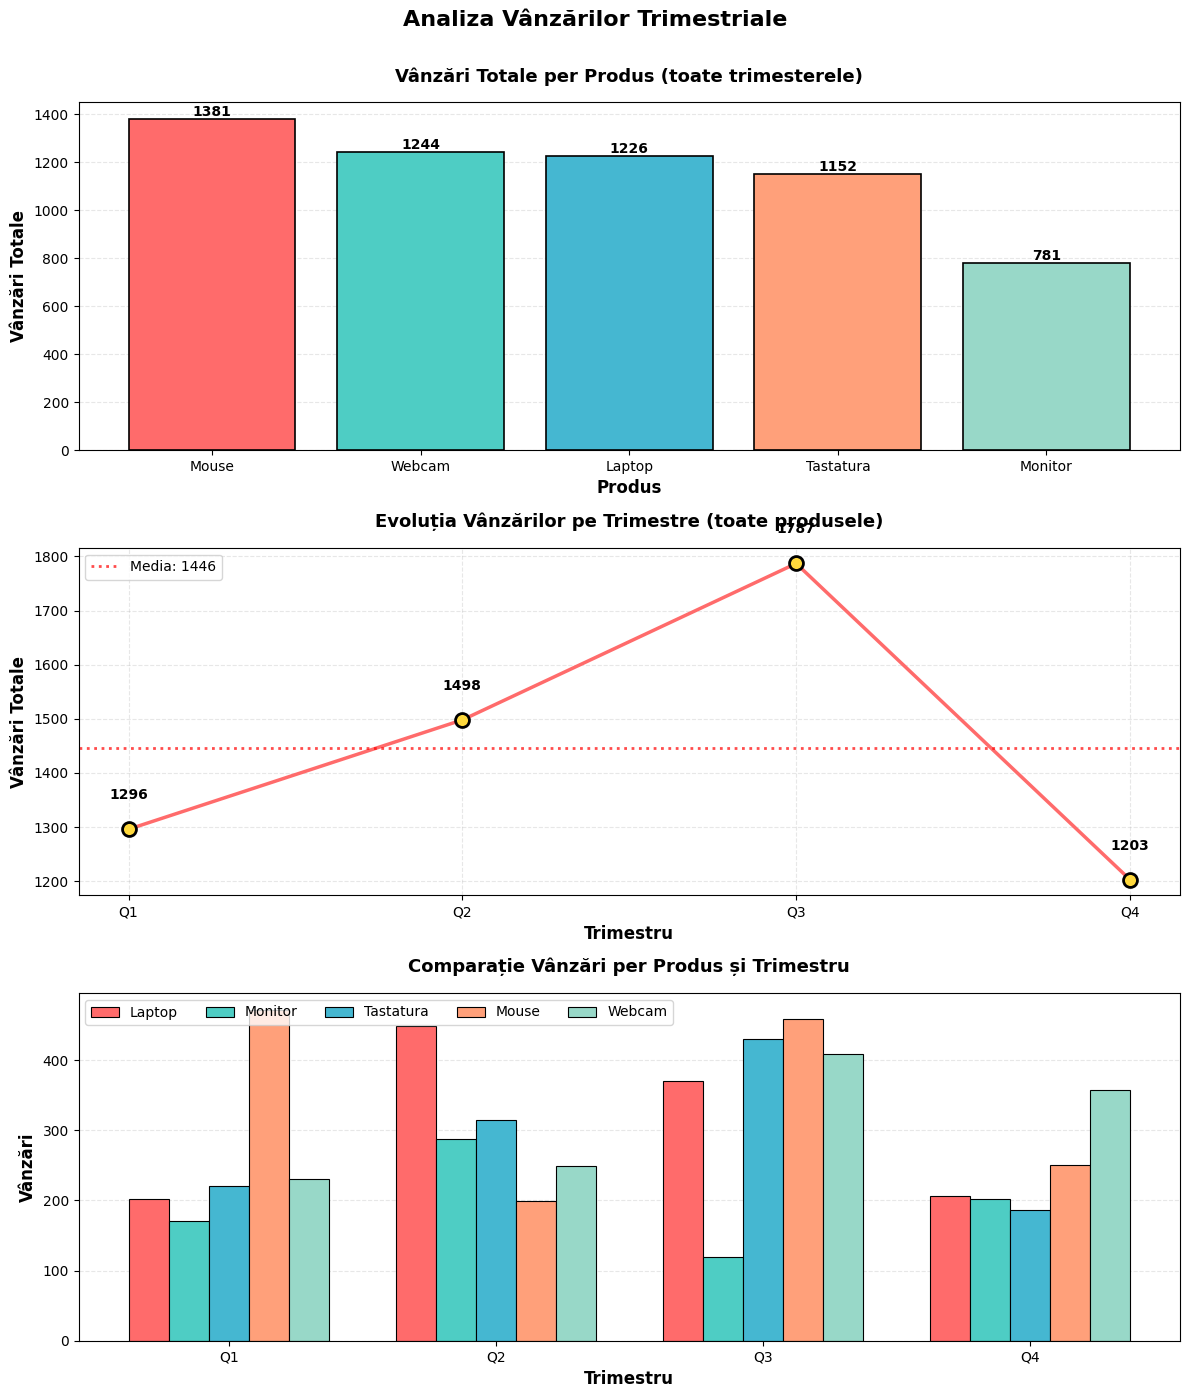

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

print("="*70)
print("EXERCIȚIUL 2: Subploturi pentru Vânzări Trimestriale")
print("="*70)

# ==================== STEP 1: Create Sales Dataset ====================
print("\n📊 STEP 1: Creare dataset vânzări")
print("="*70)

# Create quarterly sales data
produse = ['Laptop', 'Monitor', 'Tastatura', 'Mouse', 'Webcam']
trimestre = ['Q1', 'Q2', 'Q3', 'Q4']

# Generate sales data for each product and quarter
data = []
for produs in produse:
    for trimestru in trimestre:
        vanzari = np.random.randint(100, 500)
        data.append({
            'Produs': produs,
            'Trimestru': trimestru,
            'Vanzari': vanzari
        })

df = pd.DataFrame(data)

print(f"✓ Dataset creat: {len(df)} înregistrări")
print("\nPrimele 10 rânduri:")
print(df.head(10))

print("\n📈 Verificare date:")
print(f"  Produse: {df['Produs'].unique()}")
print(f"  Trimestre: {df['Trimestru'].unique()}")
print(f"  Vânzări min/max: {df['Vanzari'].min()} / {df['Vanzari'].max()}")

# ==================== STEP 2: Prepare Data for Plots ====================
print("\n" + "="*70)
print("🔄 STEP 2: Pregătire date pentru vizualizare")
print("="*70)

# Aggregate data for different views

# 1. Total sales per product (sum across all quarters)
vanzari_per_produs = df.groupby('Produs')['Vanzari'].sum().sort_values(ascending=False)
print("\nVânzări totale per produs:")
print(vanzari_per_produs)

# 2. Total sales per quarter (sum across all products)
vanzari_per_trimestru = df.groupby('Trimestru')['Vanzari'].sum()
# Ensure quarters are in correct order
vanzari_per_trimestru = vanzari_per_trimestru.reindex(['Q1', 'Q2', 'Q3', 'Q4'])
print("\nVânzări totale per trimestru:")
print(vanzari_per_trimestru)

# 3. Create pivot table for heatmap-style view (bonus for subplot 3)
pivot_data = df.pivot_table(values='Vanzari', index='Produs', columns='Trimestru', aggfunc='sum')
print("\nTabel pivot (Produs × Trimestru):")
print(pivot_data)

# ==================== STEP 3: Create Figure with 3 Subplots ====================
print("\n" + "="*70)
print("🎨 STEP 3: Creare figură cu 3 subploturi")
print("="*70)

# Create figure with 3 subplots (3 rows, 1 column)
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Add overall title
fig.suptitle('Analiza Vânzărilor Trimestriale', 
             fontsize=16, fontweight='bold', y=0.995)

print("✓ Figură creată cu 3 subploturi")

# ==================== SUBPLOT 1: Bar Chart - Sales by Product ====================
print("\n📊 SUBPLOT 1: Grafic cu bare - Vânzări per produs")

ax1 = axes[0]

# Create bar chart
bars = ax1.bar(vanzari_per_produs.index, 
               vanzari_per_produs.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
               edgecolor='black',
               linewidth=1.2)

# Customize
ax1.set_xlabel('Produs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Vânzări Totale', fontsize=12, fontweight='bold')
ax1.set_title('Vânzări Totale per Produs (toate trimesterele)', 
              fontsize=13, fontweight='bold', pad=15)

# Add grid (horizontal only)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)  # Grid behind bars

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Rotate x-axis labels if needed
ax1.tick_params(axis='x', rotation=0)

print("✓ Subplot 1 completat: Bar chart")

# ==================== SUBPLOT 2: Line Chart - Sales by Quarter ====================
print("\n📈 SUBPLOT 2: Grafic cu linii - Evoluție per trimestru")

ax2 = axes[1]

# Create line chart
ax2.plot(vanzari_per_trimestru.index, 
         vanzari_per_trimestru.values,
         marker='o', 
         markersize=10,
         linewidth=2.5,
         color='#FF6B6B',
         markerfacecolor='#FFD93D',
         markeredgecolor='black',
         markeredgewidth=2)

# Customize
ax2.set_xlabel('Trimestru', fontsize=12, fontweight='bold')
ax2.set_ylabel('Vânzări Totale', fontsize=12, fontweight='bold')
ax2.set_title('Evoluția Vânzărilor pe Trimestre (toate produsele)', 
              fontsize=13, fontweight='bold', pad=15)

# Add grid
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add value labels on points
for x, y in zip(vanzari_per_trimestru.index, vanzari_per_trimestru.values):
    ax2.text(x, y + 50, f'{int(y)}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add reference line (mean)
mean_vanzari = vanzari_per_trimestru.mean()
ax2.axhline(y=mean_vanzari, color='red', linestyle=':', 
            linewidth=2, alpha=0.7, label=f'Media: {int(mean_vanzari)}')
ax2.legend(loc='upper left', fontsize=10)

print("✓ Subplot 2 completat: Line chart cu linie de referință")

# ==================== SUBPLOT 3: Stacked Bar - Sales by Product per Quarter ====================
print("\n📊 SUBPLOT 3: Bare stivuite - Distribuție produs/trimestru")

ax3 = axes[2]

# Prepare data for stacked bar
x = np.arange(len(trimestre))
width = 0.15  # Width of bars

# Colors for each product
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Create bars for each product
for idx, produs in enumerate(produse):
    vanzari = pivot_data.loc[produs].values
    ax3.bar(x + idx * width, vanzari, width, 
            label=produs, color=colors[idx], 
            edgecolor='black', linewidth=0.8)

# Customize
ax3.set_xlabel('Trimestru', fontsize=12, fontweight='bold')
ax3.set_ylabel('Vânzări', fontsize=12, fontweight='bold')
ax3.set_title('Comparație Vânzări per Produs și Trimestru', 
              fontsize=13, fontweight='bold', pad=15)

# Set x-axis ticks
ax3.set_xticks(x + width * 2)
ax3.set_xticklabels(trimestre)

# Add legend
ax3.legend(loc='upper left', fontsize=10, ncol=5)

# Add grid
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)

print("✓ Subplot 3 completat: Grouped bar chart")

# ==================== STEP 4: Final Touches ====================
print("\n" + "="*70)
print("✨ STEP 4: Finisări finale")
print("="*70)

# Adjust spacing between subplots
plt.tight_layout(rect=[0, 0, 1, 0.99])

print("✓ Layout optimizat")
print("✓ Toate subploturile sunt clare și complete")

# ==================== STEP 5: Display Summary ====================
print("\n" + "="*70)
print("📋 REZUMAT VIZUALIZARE")
print("="*70)

print("\n✅ Subplot 1 (Bar Chart):")
print(f"   - Cel mai vândut produs: {vanzari_per_produs.idxmax()}")
print(f"   - Vânzări maxime: {vanzari_per_produs.max()}")

print("\n✅ Subplot 2 (Line Chart):")
print(f"   - Trimestru cu cele mai multe vânzări: {vanzari_per_trimestru.idxmax()}")
print(f"   - Vânzări maxime: {vanzari_per_trimestru.max()}")
print(f"   - Media trimestrială: {vanzari_per_trimestru.mean():.0f}")

print("\n✅ Subplot 3 (Grouped Bar):")
print(f"   - Arată distribuția detaliată pe produse și trimestre")
print(f"   - Permite comparații directe")

print("\n" + "="*70)
print("✅ EXERCIȚIUL 2 COMPLETAT!")
print("="*70)
print("\n💡 TIP: Graficele folosesc Pandas backend integrat cu Matplotlib")
print("💡 TIP: Personalizare completă: tick-uri, grilă, linii de referință")

# Show the plot
plt.show()


### Exercițiul 3 – Heatmap de temperaturi cu personalizare completă
Generează o matrice de temperaturi (de exemplu, 12 luni × 24 ore sau orașe × luni) și afișeaz-o ca heatmap cu `imshow` ori `pcolormesh`, adăugând o bară de culori. Personalizează tick-urile cu etichete semnificative, inserează valori direct pe celule cu contrast lizibil și experimentează cu două stiluri Matplotlib (`seaborn`, `fivethirtyeight` etc.) pentru a compara lizibilitatea.


### Exercițiul 4 – Interval de încredere cu fill_between
Pornește de la o serie (cum ar fi o medie mobilă) și construiește limite inferioare și superioare, apoi folosește `fill_between` pentru a evidenția zona dintre ele. Adaugă legendă și o adnotare care explică intervalul, ajustează grila și limitele axelor pentru claritate și experimentează cu transparența sau pattern-uri pentru zona umplută.


### Exercițiul 5 – Prezentare în stil dark_background
Recreează un grafic din setul tău folosind stilul `dark_background`, reglând culorile liniilor, markerilor și textului pentru un contrast optim. Personalizează tick-urile și grid-ul astfel încât să rămână vizibile pe fundal închis, adaugă adnotări și linii de referință relevante și exportă figura la o rezoluție potrivită pentru rapoarte sau slide-uri.


EXERCIȚIUL 5: Prezentare în Stil Dark Background

📊 STEP 1: Creare date pentru vizualizare
✓ Date generate pentru 12 luni
✓ 3 categorii de produse: Laptop, Monitor, Accesorii

🔆 STEP 2: Grafic NORMAL (pentru comparație)
✓ Grafic normal creat (fundal alb)
💾 Salvat ca 'vanzari_normal.png'

🌙 STEP 3: Grafic DARK BACKGROUND
✓ Stil 'dark_background' aplicat
✓ Grafic dark background creat cu personalizări complete

💾 STEP 4: Salvare la rezoluție înaltă
✓ Salvat ca 'vanzari_dark.png' (300 DPI - high quality)
✓ Salvat ca 'vanzari_dark.pdf' (vector - infinite zoom!)

🔄 STEP 5: Comparație Side-by-Side (Normal vs Dark)
✓ Salvat comparație ca 'comparatie_styles.png'

🔄 Style resetat la 'default' pentru viitoare grafice


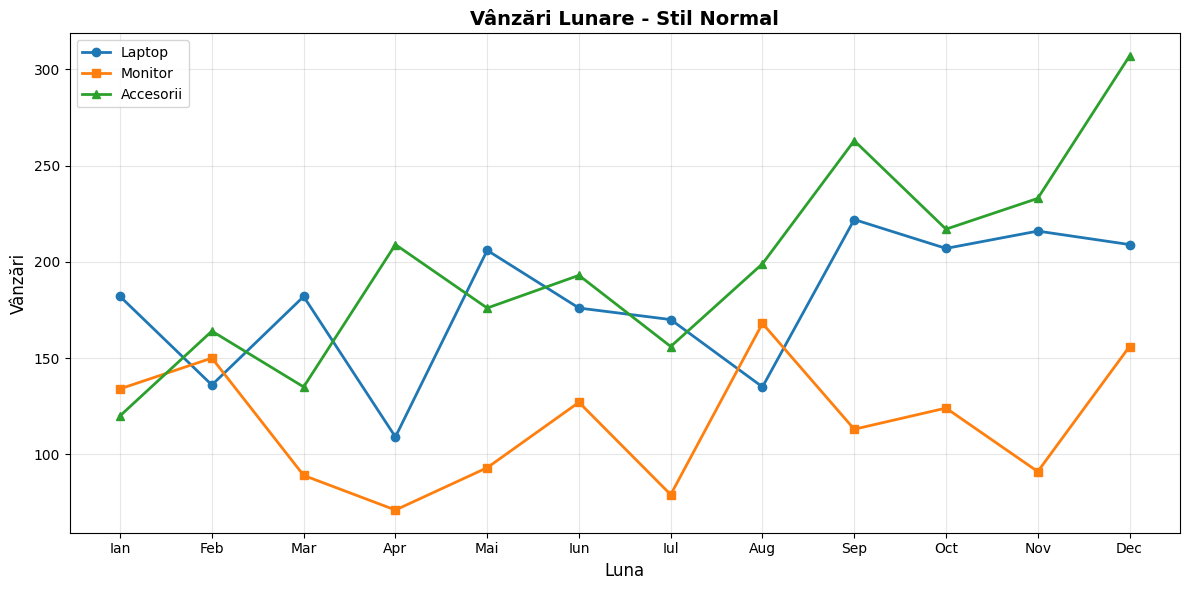

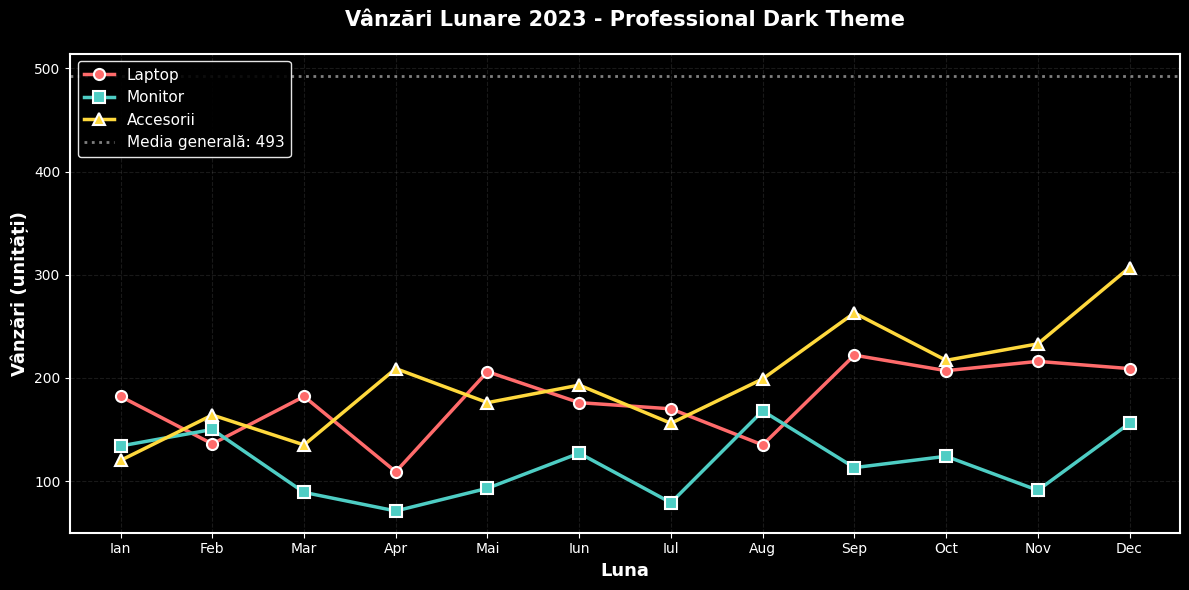

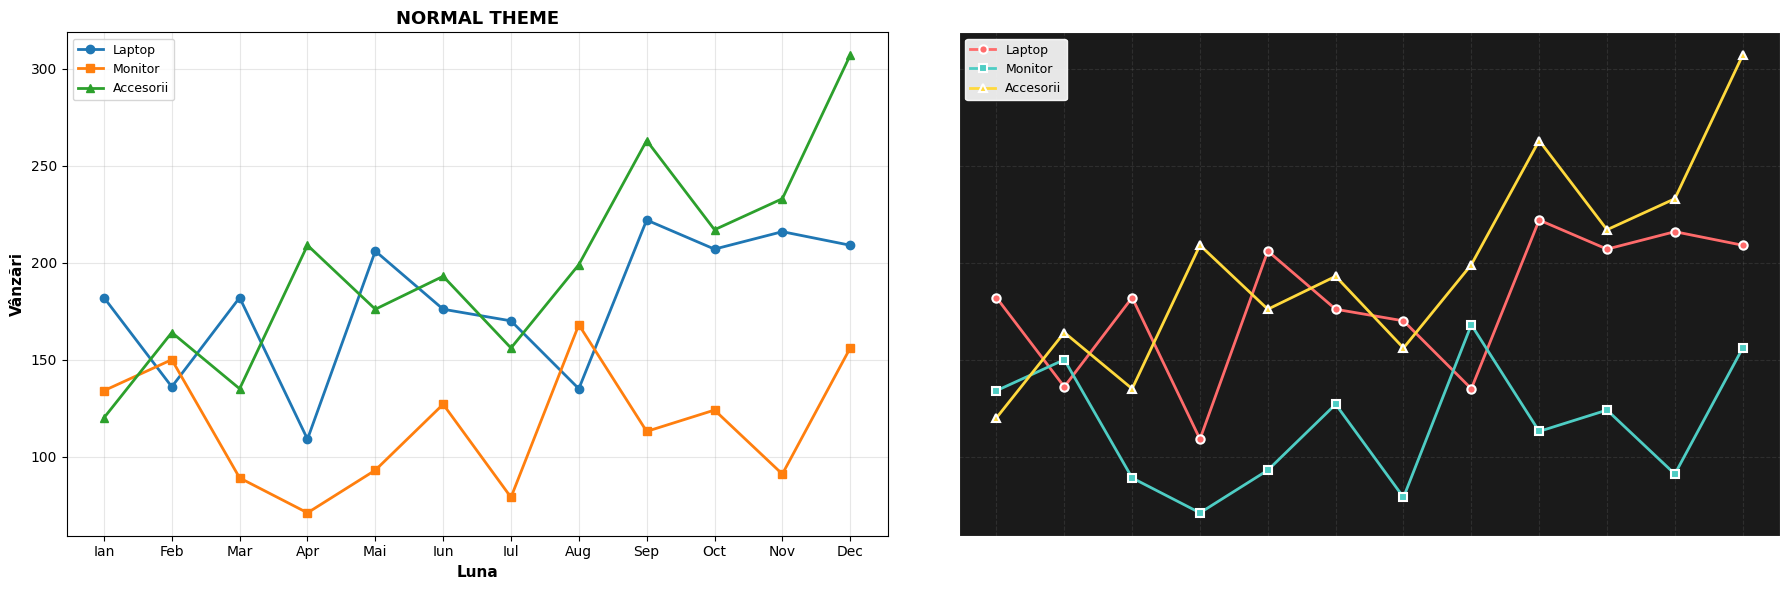

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

print("="*70)
print("EXERCIȚIUL 5: Prezentare în Stil Dark Background")
print("="*70)

# ==================== STEP 1: Create Sample Data ====================
print("\n📊 STEP 1: Creare date pentru vizualizare")
print("="*70)

# Create monthly sales data
luni = ['Ian', 'Feb', 'Mar', 'Apr', 'Mai', 'Iun', 
        'Iul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Three product lines
laptop_sales = np.random.randint(80, 200, size=12)
monitor_sales = np.random.randint(60, 150, size=12)
accesorii_sales = np.random.randint(100, 250, size=12)

# Add some trend (growth over year)
for i in range(12):
    laptop_sales[i] += i * 5
    monitor_sales[i] += i * 3
    accesorii_sales[i] += i * 7

print(f"✓ Date generate pentru {len(luni)} luni")
print(f"✓ 3 categorii de produse: Laptop, Monitor, Accesorii")

# ==================== STEP 2: Create Chart WITHOUT Dark Style (comparison) ====================
print("\n" + "="*70)
print("🔆 STEP 2: Grafic NORMAL (pentru comparație)")
print("="*70)

fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(luni, laptop_sales, marker='o', linewidth=2, label='Laptop')
ax1.plot(luni, monitor_sales, marker='s', linewidth=2, label='Monitor')
ax1.plot(luni, accesorii_sales, marker='^', linewidth=2, label='Accesorii')

ax1.set_xlabel('Luna', fontsize=12)
ax1.set_ylabel('Vânzări', fontsize=12)
ax1.set_title('Vânzări Lunare - Stil Normal', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
print("✓ Grafic normal creat (fundal alb)")

# Save normal version
plt.savefig('vanzari_normal.png', dpi=300, bbox_inches='tight')
print("💾 Salvat ca 'vanzari_normal.png'")

# ==================== STEP 3: Create Chart WITH Dark Background ====================
print("\n" + "="*70)
print("🌙 STEP 3: Grafic DARK BACKGROUND")
print("="*70)

# Apply dark background style
plt.style.use('dark_background')
print("✓ Stil 'dark_background' aplicat")

# Create figure
fig2, ax2 = plt.subplots(figsize=(12, 6))

# Plot with colors that POP on dark background
ax2.plot(luni, laptop_sales, 
         marker='o', 
         markersize=8,
         linewidth=2.5, 
         label='Laptop',
         color='#FF6B6B',  # Coral red
         markerfacecolor='#FF6B6B',
         markeredgecolor='white',
         markeredgewidth=1.5)

ax2.plot(luni, monitor_sales, 
         marker='s', 
         markersize=8,
         linewidth=2.5, 
         label='Monitor',
         color='#4ECDC4',  # Turquoise
         markerfacecolor='#4ECDC4',
         markeredgecolor='white',
         markeredgewidth=1.5)

ax2.plot(luni, accesorii_sales, 
         marker='^', 
         markersize=9,
         linewidth=2.5, 
         label='Accesorii',
         color='#FFD93D',  # Golden yellow
         markerfacecolor='#FFD93D',
         markeredgecolor='white',
         markeredgewidth=1.5)

# Customize labels and title (use light colors)
ax2.set_xlabel('Luna', fontsize=13, fontweight='bold', color='white')
ax2.set_ylabel('Vânzări (unități)', fontsize=13, fontweight='bold', color='white')
ax2.set_title('Vânzări Lunare 2023 - Professional Dark Theme', 
              fontsize=15, fontweight='bold', color='white', pad=20)

# Customize legend
ax2.legend(fontsize=11, 
           loc='upper left',
           framealpha=0.9,
           edgecolor='white',
           fancybox=True,
           shadow=True)

# Customize grid (lighter and more subtle)
ax2.grid(True, alpha=0.2, linestyle='--', color='gray')

# Customize tick colors
ax2.tick_params(axis='x', colors='white', labelsize=10)
ax2.tick_params(axis='y', colors='white', labelsize=10)

# Add reference line (average)
avg_total = (laptop_sales + monitor_sales + accesorii_sales).mean()
ax2.axhline(y=avg_total, 
            color='white', 
            linestyle=':', 
            linewidth=2, 
            alpha=0.5,
            label=f'Media generală: {avg_total:.0f}')

# Update legend to include reference line
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles, labels, fontsize=11, 
           loc='upper left',
           framealpha=0.9,
           edgecolor='white')

# Customize spine colors (the box around the plot)
for spine in ax2.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(1.5)

plt.tight_layout()
print("✓ Grafic dark background creat cu personalizări complete")

# ==================== STEP 4: Save High-Resolution Version ====================
print("\n" + "="*70)
print("💾 STEP 4: Salvare la rezoluție înaltă")
print("="*70)

# Save at different resolutions
plt.savefig('vanzari_dark.png', 
            dpi=300, 
            bbox_inches='tight',
            facecolor='#1a1a1a',  # Ensure dark background in saved file
            edgecolor='none')
print("✓ Salvat ca 'vanzari_dark.png' (300 DPI - high quality)")

plt.savefig('vanzari_dark.pdf', 
            bbox_inches='tight',
            facecolor='#1a1a1a')
print("✓ Salvat ca 'vanzari_dark.pdf' (vector - infinite zoom!)")

# ==================== STEP 5: Create Side-by-Side Comparison ====================
print("\n" + "="*70)
print("🔄 STEP 5: Comparație Side-by-Side (Normal vs Dark)")
print("="*70)

# Reset to default style for left subplot
plt.style.use('default')

# Create figure with 2 subplots
fig3, axes = plt.subplots(1, 2, figsize=(18, 6))

# LEFT: Normal style
ax_normal = axes[0]
ax_normal.plot(luni, laptop_sales, marker='o', linewidth=2, label='Laptop', color='#1f77b4')
ax_normal.plot(luni, monitor_sales, marker='s', linewidth=2, label='Monitor', color='#ff7f0e')
ax_normal.plot(luni, accesorii_sales, marker='^', linewidth=2, label='Accesorii', color='#2ca02c')
ax_normal.set_xlabel('Luna', fontsize=11, fontweight='bold')
ax_normal.set_ylabel('Vânzări', fontsize=11, fontweight='bold')
ax_normal.set_title('NORMAL THEME', fontsize=13, fontweight='bold')
ax_normal.legend(fontsize=9)
ax_normal.grid(True, alpha=0.3)

# RIGHT: Dark style (we'll manually set dark background)
ax_dark = axes[1]
ax_dark.set_facecolor('#1a1a1a')
fig3.patch.set_facecolor('white')  # Keep figure white, only subplot dark

ax_dark.plot(luni, laptop_sales, marker='o', linewidth=2, label='Laptop', 
             color='#FF6B6B', markeredgecolor='white', markeredgewidth=1.5)
ax_dark.plot(luni, monitor_sales, marker='s', linewidth=2, label='Monitor', 
             color='#4ECDC4', markeredgecolor='white', markeredgewidth=1.5)
ax_dark.plot(luni, accesorii_sales, marker='^', linewidth=2, label='Accesorii', 
             color='#FFD93D', markeredgecolor='white', markeredgewidth=1.5)

ax_dark.set_xlabel('Luna', fontsize=11, fontweight='bold', color='white')
ax_dark.set_ylabel('Vânzări', fontsize=11, fontweight='bold', color='white')
ax_dark.set_title('DARK THEME', fontsize=13, fontweight='bold', color='white')
ax_dark.legend(fontsize=9, framealpha=0.9, edgecolor='white')
ax_dark.grid(True, alpha=0.2, linestyle='--', color='gray')
ax_dark.tick_params(colors='white')

for spine in ax_dark.spines.values():
    spine.set_edgecolor('white')

plt.tight_layout()
plt.savefig('comparatie_styles.png', dpi=300, bbox_inches='tight')
print("✓ Salvat comparație ca 'comparatie_styles.png'")


# Reset style to default for future plots
plt.style.use('default')
print("\n🔄 Style resetat la 'default' pentru viitoare grafice")

# Show all plots
plt.show()